In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/iris.csv")

Exploração inicial do conjunto de dados.

Identificar as colunas de características, a target class, os tipos de dados e verificar se existem valores em falta.
A coluna ID será ignorada porque é apenas um identificador de linha e não representa uma característica da flor.

In [3]:
df.head()

,ID,sepallength,sepalwidth,petallength,petalwidth,class
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           150 non-null    int64  
 1   sepallength  150 non-null    float64
 2   sepalwidth   150 non-null    float64
 3   petallength  150 non-null    float64
 4   petalwidth   150 non-null    float64
 5   class        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
df.describe()

,ID,sepallength,sepalwidth,petallength,petalwidth
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.shape

(150, 6)

In [7]:
cols = df.columns

In [8]:
cols

Index(['ID', 'sepallength', 'sepalwidth', 'petallength', 'petalwidth',
       'class'],
      dtype='str')

In [9]:
df["class"].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
df.isnull().sum()

ID             0
sepallength    0
sepalwidth     0
petallength    0
petalwidth     0
class          0
dtype: int64

CONCLUSAO: O dataset está equilibrado: cada classe de íris tem 50 exemplos. Não há valores em falta em nenhuma coluna. As colunas de características úteis são sepallength, sepalwidth, petallength e petalwidth. A coluna de destino é class.

Divisão em treino e teste

Divididir o conjunto de dados em dois subconjuntos: um conjunto de treino/desenvolvimento (80%) e um conjunto de teste final (20%). Como o conjunto de dados Iris tem três classes equilibradas, usamos uma divisão estratificada, garantindo que cada classe mantém aproximadamente a mesma proporção nos dois subconjuntos.

O conjunto de treino será usado para ajustar a discretização, construir a árvore de decisão e comparar configurações. O conjunto de teste será mantido separado e usado apenas no fim para avaliar o desempenho final do modelo.

In [11]:
train_df = df.groupby("class", group_keys=False).sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

In [12]:
train_df.shape

(120, 6)

In [13]:
test_df.shape

(30, 6)

In [14]:
test_df.head()

,ID,sepallength,sepalwidth,petallength,petalwidth,class
7,8,5.0,3.4,1.5,0.2,Iris-setosa
10,11,5.4,3.7,1.5,0.2,Iris-setosa
14,15,5.8,4.0,1.2,0.2,Iris-setosa
18,19,5.7,3.8,1.7,0.3,Iris-setosa
20,21,5.4,3.4,1.7,0.2,Iris-setosa


In [15]:
train_df.head()

,ID,sepallength,sepalwidth,petallength,petalwidth,class
13,14,4.3,3.0,1.1,0.1,Iris-setosa
39,40,5.1,3.4,1.5,0.2,Iris-setosa
30,31,4.8,3.1,1.6,0.2,Iris-setosa
45,46,4.8,3.0,1.4,0.3,Iris-setosa
17,18,5.1,3.5,1.4,0.3,Iris-setosa


In [16]:
train_df["class"].value_counts()

class
Iris-setosa        40
Iris-versicolor    40
Iris-virginica     40
Name: count, dtype: int64

In [17]:
test_df["class"].value_counts()

class
Iris-setosa        10
Iris-versicolor    10
Iris-virginica     10
Name: count, dtype: int64

A divisão manteve a distribuição das classes: o conjunto de treino contém 40 exemplos de cada classe e o conjunto de teste contém 10 exemplos de cada classe. Isto confirma que a divisão estratificada preservou o equilíbrio original do conjunto de dados.

In [18]:
feature_columns = ["sepallength", "sepalwidth", "petallength", "petalwidth"]
target_column = "class"

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

In [19]:
X_train.shape

(120, 4)

In [20]:
y_train.shape

(120,)

In [21]:
X_test.shape

(30, 4)

In [22]:
y_test.shape

(30,)

Discretização das características numéricas

O algoritmo ID3 trabalha naturalmente com atributos categóricos. Como as características do conjunto Iris são numéricas contínuas, precisamos de as converter em categorias antes de treinar a árvore de decisão. Este processo chama-se discretização.

A discretização será ajustada apenas com os dados de treino, para evitar fuga de informação do conjunto de teste. Depois de definidos os intervalos com base no treino, os mesmos intervalos serão aplicados ao conjunto de teste.

In [23]:
from src.discretizer import apply_bins, learn_bins

In [24]:
bin_rules_width = learn_bins(
    X_train, columns=feature_columns, n_bins=3, method="equal_width"
)

X_train_width = apply_bins(X_train, bin_rules_width)
X_test_width = apply_bins(X_test, bin_rules_width)

In [25]:
X_train_width.sample(10, random_state=1)

,sepallength,sepalwidth,petallength,petalwidth
139,bin_2,bin_1,bin_2,bin_2
71,bin_1,bin_0,bin_1,bin_1
81,bin_0,bin_0,bin_1,bin_1
148,bin_1,bin_1,bin_2,bin_2
53,bin_0,bin_0,bin_1,bin_1
72,bin_1,bin_0,bin_1,bin_1
11,bin_0,bin_1,bin_0,bin_0
149,bin_1,bin_1,bin_2,bin_2
60,bin_0,bin_0,bin_1,bin_1
124,bin_1,bin_1,bin_2,bin_2


In [26]:
X_test_width.sample(10, random_state=1)

,sepallength,sepalwidth,petallength,petalwidth
77,bin_1,bin_1,bin_2,bin_1
107,bin_2,bin_1,bin_2,bin_2
51,bin_1,bin_1,bin_1,bin_1
93,bin_0,bin_0,bin_1,bin_1
63,bin_1,bin_1,bin_1,bin_1
104,bin_1,bin_1,bin_2,bin_2
138,bin_1,bin_1,bin_1,bin_2
18,bin_1,bin_2,bin_0,bin_0
132,bin_1,bin_0,bin_2,bin_2
116,bin_1,bin_1,bin_2,bin_2


In [27]:
bin_rules_frequency = learn_bins(
    X_train, columns=feature_columns, n_bins=3, method="equal_frequency"
)

X_train_frequency = apply_bins(X_train, bin_rules_frequency)
X_test_frequency = apply_bins(X_test, bin_rules_frequency)

In [28]:
X_train_frequency.sample(10, random_state=1)

,sepallength,sepalwidth,petallength,petalwidth
139,bin_2,bin_1,bin_2,bin_2
71,bin_1,bin_0,bin_1,bin_1
81,bin_1,bin_0,bin_1,bin_0
148,bin_1,bin_2,bin_2,bin_2
53,bin_1,bin_0,bin_1,bin_1
72,bin_2,bin_0,bin_1,bin_1
11,bin_0,bin_2,bin_0,bin_0
149,bin_1,bin_1,bin_2,bin_2
60,bin_0,bin_0,bin_1,bin_0
124,bin_2,bin_2,bin_2,bin_2


Foram testados dois métodos de discretização: largura igual (equal_width) e frequência igual (equal_frequency). Em ambos os casos, as regras foram aprendidas apenas com X_train e depois aplicadas a X_train e X_test.

A discretização manteve o número de linhas e colunas dos conjuntos de dados, mas substituiu os valores numéricos por categorias discretas, como bin_0, bin_1 e bin_2.

Métricas para o ID3: entropia e ganho de informação

Nesta etapa foram implementadas e testadas as métricas necessárias para o algoritmo ID3.

O algoritmo ID3 precisa de uma forma quantitativa de escolher o melhor atributo para dividir os dados em cada nó da árvore. Para isso, usamos três conceitos principais:

- Entropy: mede a impureza ou incerteza das classes.
- Conditional Entropy: mede a incerteza que resta depois de dividir os dados por um atributo.
- Information Gain: mede quanto a incerteza diminui depois de usar um atributo para dividir os dados.


In [29]:
from src.decision_tree.metrics import best_attribute, conditional_entropy

In [30]:
conditional_entropy(["bin_0", "bin_0", "bin_1", "bin_1"], ["yes", "yes", "yes", "no"])

0.5

In [31]:
best_column_width, best_gain_width, gains_width = best_attribute(X_train_width, y_train)

best_column_width, best_gain_width, gains_width

('petalwidth',
 1.3697027307802359,
 {'sepallength': 0.6725350563088384,
  'sepalwidth': 0.2802830870667474,
  'petallength': 1.3143702580874352,
  'petalwidth': 1.3697027307802359})

In [32]:
best_column_frequency, best_gain_frequency, gains_frequency = best_attribute(
    X_train_frequency, y_train
)

best_column_frequency, best_gain_frequency, gains_frequency

('petallength',
 1.3143702580874352,
 {'sepallength': 0.7721576067541941,
  'sepalwidth': 0.3291243182868424,
  'petallength': 1.3143702580874352,
  'petalwidth': 1.2154687801287787})

In [33]:
pd.DataFrame(
    {"equal_width": gains_width, "equal_frequency": gains_frequency}
).sort_values(by="equal_width", ascending=False)

,equal_width,equal_frequency
petalwidth,1.369703,1.215469
petallength,1.314370,1.314370
sepallength,0.672535,0.772158
sepalwidth,0.280283,0.329124


A tabela acima mostra o ganho de informação de cada atributo para os dois métodos de discretização:

equal_width: discretização por largura igual.
equal_frequency: discretização por frequência igual.
    
Para a discretização por largura igual, o atributo com maior ganho de informação foi petalwidth.

Para a discretização por frequência igual, o atributo com maior ganho de informação foi petallength.

Estes resultados fazem sentido, porque no conjunto de dados Iris as medidas das pétalas tendem a separar melhor as três classes do que as medidas das sépalas.

Assim, estas métricas confirmam que as funções implementadas estão a produzir resultados coerentes e podem agora ser usadas na construção da árvore de decisão com ID3.

Construção da árvore de decisão com ID3

Depois de calcular as métricas necessárias, usamos agora o algoritmo ID3 para construir a árvore de decisão.

O ID3 escolhe, em cada nó, o atributo com maior ganho de informação. Esse atributo passa a ser a pergunta feita nesse nó da árvore. Depois, os dados são divididos de acordo com os valores desse atributo (bin_0, bin_1, bin_2) e o mesmo processo é repetido recursivamente em cada ramo.

Nesta primeira experiência, usamos os dados discretizados pelo método equal_width.

In [34]:
from src.decision_tree.id3_decision_tree import ID3DecisionTree

tree_width = ID3DecisionTree()
tree_width.fit(X_train_width, y_train)

tree_width

In [35]:
tree_width.print_tree()

Attribute: petalwidth
If petalwidth == bin_0:
    Predict: Iris-setosa
If petalwidth == bin_1:
    Attribute: petallength
    If petallength == bin_1:
        Predict: Iris-versicolor
    If petallength == bin_2:
        Predict: Iris-virginica
    If petallength == bin_0:
        Predict: Iris-versicolor
If petalwidth == bin_2:
    Attribute: petallength
    If petallength == bin_1:
        Attribute: sepalwidth
        If sepalwidth == bin_1:
            Predict: Iris-versicolor
        If sepalwidth == bin_0:
            Predict: Iris-virginica
    If petallength == bin_2:
        Predict: Iris-virginica


A função print_tree mostra a árvore completa de forma legível.

Cada linha "Attribute" representa um nó de decisão, ou seja, uma pergunta feita pela árvore.  
Cada linha "If ..." representa um ramo criado por um valor possível desse atributo.  
Cada linha "Predict" representa uma folha da árvore, onde é feita uma previsão final da classe.

Avaliação no conjunto de teste

Depois de construir as árvores com os dados de treino, usamos o conjunto de teste para avaliar o desempenho do modelo em exemplos não usados durante o treino.

A métrica usada foi a accuracy, que mede a proporção de previsões corretas. Foram comparadas duas versões da discretização: "equal_width" e "equal_frequency".

In [36]:
from src.decision_tree.id3_decision_tree import ID3DecisionTree
import pandas as pd


def accuracy_score(y_true, y_pred):
    """
    Calculates accuracy = correct predictions / total predictions.
    """
    y_true = list(y_true)
    y_pred = list(y_pred)

    correct = 0

    for actual, predicted in zip(y_true, y_pred):
        if actual == predicted:
            correct += 1

    accuracy = correct / len(y_true)

    return accuracy


# Train and evaluate equal_width tree

tree_width = ID3DecisionTree()
tree_width.fit(X_train_width, y_train)

predictions_width = tree_width.predict(X_test_width)
accuracy_width = accuracy_score(y_test, predictions_width)


# Train and evaluate equal_frequency tree

tree_frequency = ID3DecisionTree()
tree_frequency.fit(X_train_frequency, y_train)

predictions_frequency = tree_frequency.predict(X_test_frequency)
accuracy_frequency = accuracy_score(y_test, predictions_frequency)



# Store results in a table


results = pd.DataFrame(
    {
        "method": ["equal_width", "equal_frequency"],
        "accuracy": [accuracy_width, accuracy_frequency],
    }
)

results["accuracy_percent"] = results["accuracy"] * 100

results

,method,accuracy,accuracy_percent
0,equal_width,0.900000,90.000000
1,equal_frequency,0.866667,86.666667


A tabela mostra a accuracy obtida pelas duas versões da árvore ID3, usando os dois métodos de discretização implementados.

A discretização foi usada porque o conjunto Iris contém valores numéricos contínuos. Ao transformar esses valores em categorias como bin_0, bin_1 e bin_2, o ID3 consegue criar divisões categóricas e manter a árvore mais simples. Nesta fase, foi usado n_bins = 3, procurando um equilíbrio entre simplicidade da árvore e preservação de informação.

Com esta divisão treino/teste, a discretização equal_width obteve uma accuracy de 90%, enquanto a discretização equal_frequency obteve uma accuracy de 86.67%.

Isto significa que, no conjunto de teste, a árvore construída com equal_width classificou corretamente 90% dos exemplos, enquanto a árvore construída com equal_frequency classificou corretamente 86.67%.

A diferença entre os dois métodos é pequena: como o conjunto de teste tem 30 exemplos, uma diferença de 3.33% corresponde apenas a um exemplo. Por isso, estes resultados devem ser interpretados como uma comparação simples entre os dois métodos de discretização, e não como uma conclusão definitiva de que um método é sempre melhor do que o outro.

Neste caso, equal_width teve um desempenho ligeiramente superior e produziu a melhor accuracy no conjunto de teste.

In [37]:
tree_width.print_tree()

Attribute: petalwidth
If petalwidth == bin_0:
    Predict: Iris-setosa
If petalwidth == bin_1:
    Attribute: petallength
    If petallength == bin_1:
        Predict: Iris-versicolor
    If petallength == bin_2:
        Predict: Iris-virginica
    If petallength == bin_0:
        Predict: Iris-versicolor
If petalwidth == bin_2:
    Attribute: petallength
    If petallength == bin_1:
        Attribute: sepalwidth
        If sepalwidth == bin_1:
            Predict: Iris-versicolor
        If sepalwidth == bin_0:
            Predict: Iris-virginica
    If petallength == bin_2:
        Predict: Iris-virginica


,n_bins,equal_frequency,equal_width
0,2,76.67% (23/30),70.00% (21/30)
1,3,86.67% (26/30),90.00% (27/30)
2,4,93.33% (28/30),93.33% (28/30)
3,5,86.67% (26/30),90.00% (27/30)
4,6,93.33% (28/30),86.67% (26/30)
5,7,93.33% (28/30),93.33% (28/30)
6,8,96.67% (29/30),90.00% (27/30)


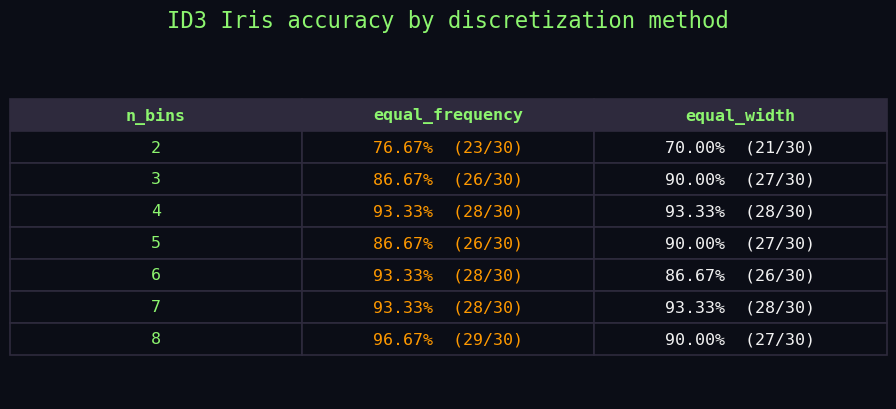

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

from src.discretizer import apply_bins, learn_bins
from src.decision_tree.id3_decision_tree import ID3DecisionTree



# Accuracy helper


def accuracy_score(y_true, y_pred):
    """
    Calculates accuracy manually.

    accuracy = number of correct predictions / total predictions
    """
    y_true = list(y_true)
    y_pred = list(y_pred)

    correct = 0

    for actual, predicted in zip(y_true, y_pred):
        if actual == predicted:
            correct += 1

    total = len(y_true)
    accuracy = correct / total

    return accuracy, correct, total


# Experiment settings

bin_sizes = range(2, 9)  # tests 2, 3, 4, 5, 6, 7, 8 bins
methods = ["equal_width", "equal_frequency"]

results_by_bins = []


# Run ID3 for each discretization method and bin size

for method in methods:
    for n_bins in bin_sizes:

        # 1. Learn bin rules ONLY from training data
        bin_rules = learn_bins(
            X_train,
            columns=feature_columns,
            n_bins=n_bins,
            method=method
        )

        # 2. Apply the same bin rules to train and test
        X_train_binned = apply_bins(X_train, bin_rules)
        X_test_binned = apply_bins(X_test, bin_rules)

        # 3. Train ID3 tree using the current class-based implementation
        tree = ID3DecisionTree()
        tree.fit(X_train_binned, y_train)

        # 4. Predict on test set
        y_pred = tree.predict(X_test_binned)

        # 5. Evaluate
        acc, correct, total = accuracy_score(y_test, y_pred)

        # 6. Store result
        results_by_bins.append({
            "method": method,
            "n_bins": n_bins,
            "correct": correct,
            "total": total,
            "accuracy": acc,
            "accuracy_percent": acc * 100
        })


# Convert results list into dataframe
results_by_bins = pd.DataFrame(results_by_bins)



# Create a table

table_for_display = results_by_bins.copy()

table_for_display["result"] = (
    table_for_display["accuracy_percent"].map(lambda x: f"{x:.2f}%")
    + "  ("
    + table_for_display["correct"].astype(str)
    + "/"
    + table_for_display["total"].astype(str)
    + ")"
)

accuracy_table = (
    table_for_display
    .pivot(index="n_bins", columns="method", values="result")
    .reset_index()
)

accuracy_table.columns.name = None

display(accuracy_table)


BG = "#0b0d16"       # near black
PANEL = "#2e2a3d"    # dark purple
TEXT = "#f2f2f2"     # white
GREEN = "#8df56f"    # slide green
PINK = "#d66ad7"     # slide pink/purple
ORANGE = "#ff9900"   # slide orange

fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=BG)
ax.set_facecolor(BG)
ax.axis("off")

table = ax.table(
    cellText=accuracy_table.values,
    colLabels=accuracy_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(PANEL)
    cell.set_linewidth(1.2)

    if row == 0:
        # Header row
        cell.set_facecolor(PANEL)
        cell.get_text().set_color(GREEN)
        cell.get_text().set_weight("bold")
    else:
        # Body rows
        cell.set_facecolor(BG)

        if col == 0:
            # n_bins column
            cell.get_text().set_color(GREEN)
        elif col == 1:
            # equal_width column
            cell.get_text().set_color(ORANGE)
        elif col == 2:
            # equal_frequency column
            cell.get_text().set_color(TEXT)
        else:
            cell.get_text().set_color(TEXT)

    cell.get_text().set_fontfamily("monospace")

ax.set_title(
    "ID3 Iris accuracy by discretization method",
    color=GREEN,
    fontsize=16,
    fontfamily="monospace",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "iris_id3_accuracy_table_dark.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)

plt.show()

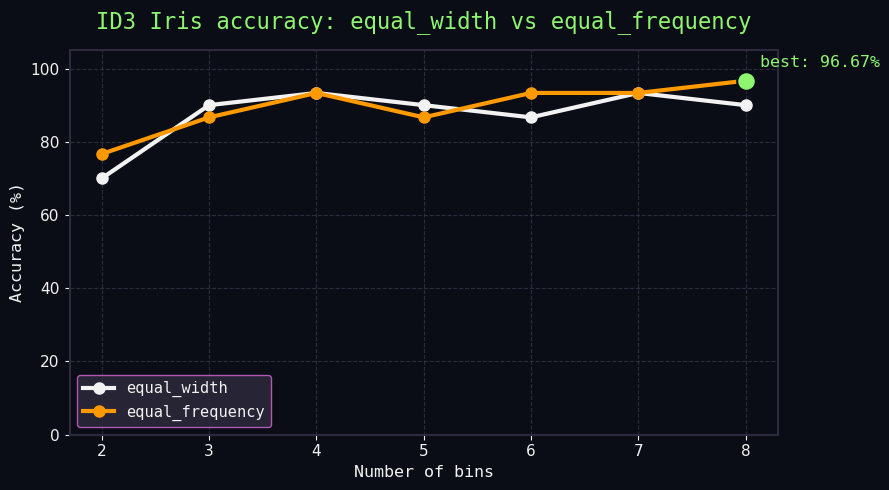

In [39]:
BG = "#0b0d16"
PANEL = "#2e2a3d"
TEXT = "#f2f2f2"
GRID = "#4a435c"
GREEN = "#8df56f"
PINK = "#d66ad7"
ORANGE = "#ff9900"

method_colours = {
    "equal_width": TEXT,
    "equal_frequency": ORANGE
}

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

for method in methods:
    subset = results_by_bins[results_by_bins["method"] == method].sort_values("n_bins")

    ax.plot(
        subset["n_bins"],
        subset["accuracy_percent"],
        marker="o",
        linewidth=3,
        markersize=8,
        color=method_colours[method],
        label=method
    )

best_row = results_by_bins.loc[results_by_bins["accuracy_percent"].idxmax()]

ax.scatter(
    best_row["n_bins"],
    best_row["accuracy_percent"],
    s=180,
    color=GREEN,
    edgecolor=BG,
    linewidth=1.5,
    zorder=5
)

ax.annotate(
    f"best: {best_row['accuracy_percent']:.2f}%",
    xy=(best_row["n_bins"], best_row["accuracy_percent"]),
    xytext=(10, 10),
    textcoords="offset points",
    color=GREEN,
    fontsize=12,
    fontfamily="monospace"
)

ax.set_title(
    "ID3 Iris accuracy: equal_width vs equal_frequency",
    color=GREEN,
    fontsize=16,
    fontfamily="monospace",
    pad=16
)

ax.set_xlabel("Number of bins", color=TEXT, fontsize=12, fontfamily="monospace")
ax.set_ylabel("Accuracy (%)", color=TEXT, fontsize=12, fontfamily="monospace")

ax.tick_params(colors=TEXT, labelsize=11)

for spine in ax.spines.values():
    spine.set_color(PANEL)
    spine.set_linewidth(1.5)

ax.grid(True, color=GRID, linestyle="--", linewidth=0.8, alpha=0.55)

ax.set_ylim(0, 105)
ax.set_xticks(list(bin_sizes))

legend = ax.legend(
    facecolor=PANEL,
    edgecolor=PINK,
    labelcolor=TEXT,
    fontsize=11
)

for text in legend.get_texts():
    text.set_fontfamily("monospace")

plt.tight_layout()

plt.savefig(
    "iris_id3_accuracy_bins_dark.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)

plt.show()

A melhor configuração neste split foi equal_frequency com 8 bins, atingindo 96.67% de accuracy.

Em geral, aumentar o número de bins permitiu à árvore ID3 usar divisões mais detalhadas dos atributos contínuos. No entanto, os resultados não aumentam de forma perfeitamente linear: algumas configurações com menos bins também obtiveram bons resultados.

Outra vez, é importante notar que o dataset tem apenas 30 exemplos, por isso uma diferença de 3.33% corresponde apenas a um exemplo classificado corretamente ou incorretamente. Assim, estes resultados indicam a melhor configuração neste experimento, mas não provam que ela será sempre a melhor em qualquer divisão treino/teste.